# Aprendizaje No Supervisado


Claster,Kmeans

In [11]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [12]:
import pandas as pd 
df=pd.read_excel('cervezas.xlsx')
df

,Unnamed: 0,Name,Calories,Sodium,Alcohol,Cost
0,0,Budweiser,144,15,4.7,0.43
1,1,Schlitz,151,19,4.9,0.43
2,2,Lowenbrau,157,15,0.9,0.48
3,3,Kronenbourg,170,7,5.2,0.73
4,4,Heineken,152,11,5.0,0.77
5,5,Old_Milwaukee,145,23,4.6,0.28
6,6,Augsberger,175,24,5.5,0.40
7,7,Srohs_Bohemian_Style,149,27,4.7,0.42
8,8,Miller_Lite,99,10,4.3,0.43
9,9,Budweiser_Light,113,8,3.7,0.40


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  20 non-null     int64  
 1   Name        20 non-null     object 
 2   Calories    20 non-null     int64  
 3   Sodium      20 non-null     int64  
 4   Alcohol     20 non-null     float64
 5   Cost        20 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


In [14]:
df.columns

Index(['Unnamed: 0', 'Name', 'Calories', 'Sodium', 'Alcohol', 'Cost'], dtype='object')

In [18]:
X=df[['Calories', 'Sodium', 'Alcohol', 'Cost']]
X.head()

,Calories,Sodium,Alcohol,Cost
0,144,15,4.7,0.43
1,151,19,4.9,0.43
2,157,15,0.9,0.48
3,170,7,5.2,0.73
4,152,11,5.0,0.77


In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled)    

[[ 0.38791334  0.00779468  0.43380786 -0.45682969]
 [ 0.6250656   0.63136906  0.62241997 -0.45682969]
 [ 0.82833896  0.00779468 -3.14982226 -0.10269815]
 [ 1.26876459 -1.23935408  0.90533814  1.66795955]
 [ 0.65894449 -0.6157797   0.71672602  1.95126478]
 [ 0.42179223  1.25494344  0.3395018  -1.5192243 ]
 [ 1.43815906  1.41083704  1.1882563  -0.66930861]
 [ 0.55730781  1.87851782  0.43380786 -0.52765599]
 [-1.1366369  -0.7716733   0.05658363 -0.45682969]
 [-0.66233238 -1.08346049 -0.5092527  -0.66930861]
 [ 0.25239776  0.47547547  0.3395018  -0.38600338]
 [-1.03500022  0.00779468 -0.13202848 -0.24435076]
 [ 0.08300329 -0.6157797  -0.03772242  0.03895447]
 [ 0.59118671  0.63136906  0.43380786  1.88043848]
 [ 0.55730781 -1.39524768  0.71672602  2.0929174 ]
 [-2.18688263  0.00779468 -1.82953748 -0.81096123]
 [ 0.21851887  0.63136906  0.15088969 -0.45682969]
 [ 0.38791334  1.41083704  0.62241997 -0.45682969]
 [-2.05136705 -1.39524768 -1.26370115 -0.24435076]
 [-1.20439469 -1.23935408 -0.03

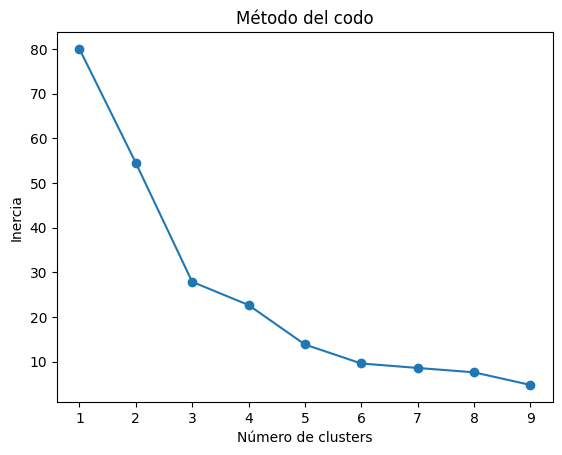

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.show()

In [22]:
from sklearn.cluster import KMeans
model_kmeans=KMeans(n_clusters=3)
model_kmeans.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [23]:
#Obtener los clusters
clusters = model_kmeans.labels_
clusters

array([2, 2, 1, 0, 0, 2, 2, 2, 1, 1, 2, 1, 1, 0, 0, 1, 2, 2, 1, 1],
      dtype=int32)

In [24]:
X['Cluster'] = clusters
X

C:\Users\l\AppData\Local\Temp\ipykernel_5536\2149051691.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cluster'] = clusters


,Calories,Sodium,Alcohol,Cost,Cluster
0,144,15,4.7,0.43,2
1,151,19,4.9,0.43,2
2,157,15,0.9,0.48,1
3,170,7,5.2,0.73,0
4,152,11,5.0,0.77,0
5,145,23,4.6,0.28,2
6,175,24,5.5,0.40,2
7,149,27,4.7,0.42,2
8,99,10,4.3,0.43,1
9,113,8,3.7,0.40,1


In [25]:
#agrupar por cluster con los valores medios
X.groupby('Cluster').mean()

,Calories,Sodium,Alcohol,Cost
Cluster,,,,
0,155.250,10.750,4.9750,0.7625
1,105.375,10.875,3.3250,0.4475
2,148.375,21.125,4.7875,0.4075


In [27]:
#Ver los centroides
print(model_kmeans.cluster_centers_)

[[ 0.7690509  -0.6547531   0.69314951  1.89814505]
 [-0.92065895 -0.6352664  -0.86290041 -0.33288365]
 [ 0.5361335   0.96264295  0.51632566 -0.61618888]]


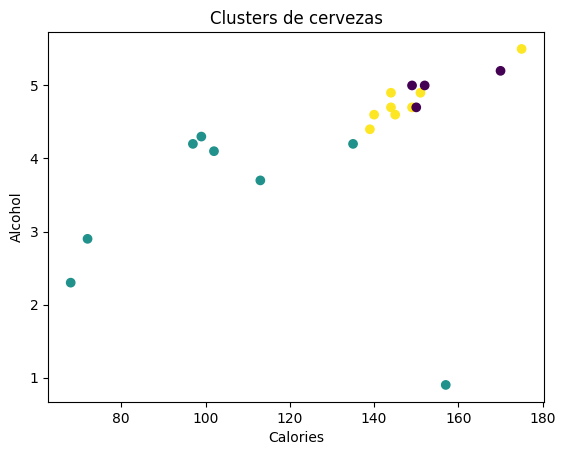

In [28]:
import matplotlib.pyplot as plt

plt.scatter(df['Calories'], df['Alcohol'], c=clusters)
plt.xlabel('Calories')
plt.ylabel('Alcohol')
plt.title('Clusters de cervezas')
plt.show()

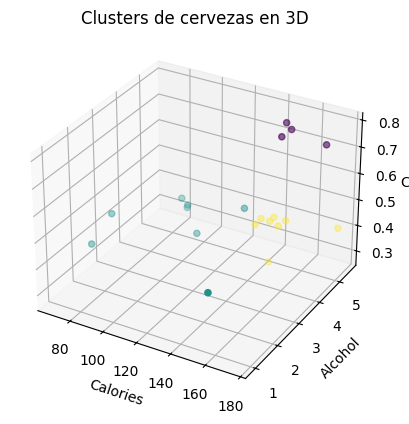

In [41]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Graficar
ax.scatter(
    X['Calories'],
    X['Alcohol'],
    X['Cost'],
    c=X['Cluster'],   # color por cluster
)

# Etiquetas
ax.set_xlabel('Calories')
ax.set_ylabel('Alcohol')
ax.set_zlabel('Cost')

plt.title('Clusters de cervezas en 3D')
plt.show()

In [42]:
#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [43]:
#Ver cuánta información conserva
pca.explained_variance_ratio_

array([0.44930633, 0.3586891 , 0.13849183])

In [46]:
#Crear DataFrame con PCA
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = X['Cluster']

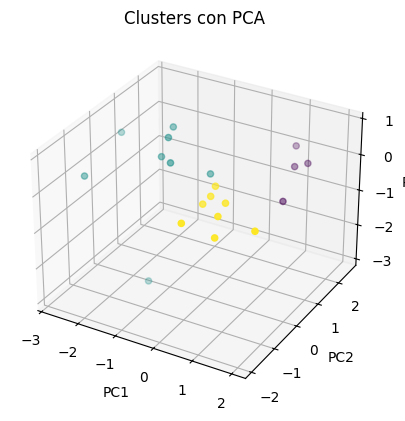

In [47]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    df_pca['PC3'],
    c=df_pca['Cluster']
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.title('Clusters con PCA')
plt.show()

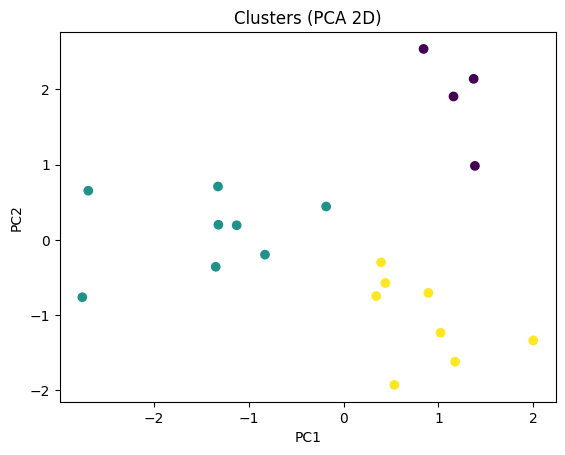

In [48]:
plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_pca['Cluster']
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters (PCA 2D)')
plt.show()

In [49]:
#peso de las variables
pca.components_

array([[ 0.66372138,  0.36690842,  0.59441604,  0.26743543],
       [ 0.00168485, -0.67844482,  0.08878928,  0.72926418],
       [-0.51029916, -0.17943268,  0.79888756, -0.26301586]])

          Calories	    Sodium	     Alcohol	   Cost
array([[ 0.66372138,  0.36690842,  0.59441604,  0.26743543],  PCA1 mas influenciado por las calorias y alcohol
       [ 0.00168485, -0.67844482,  0.08878928,  0.72926418],  PCA2 mas influenciado por el sodio y el costo
       [-0.51029916, -0.17943268,  0.79888756, -0.26301586]]) PCA3 mas influenciado por las calorias y alcohol


In [ ]:
Calories	Sodium	Alcohol	Cost

## DBSCAN

1. Diferencia clave (KMeans vs DBSCAN)
             KMeans	                          DBSCAN
Necesita K (n° clusters)            	❌ No necesita K
Usa centroides	                        ❌ No usa centroides
Forma clusters “circulares”	            ✔ Detecta formas raras
Todos los puntos tienen cluster     	❌ Puede haber ruido (-1)

👉 DBSCAN agrupa por densidad, no por distancia al centro

In [32]:
X_scaled

array([[ 0.38791334,  0.00779468,  0.43380786, -0.45682969],
       [ 0.6250656 ,  0.63136906,  0.62241997, -0.45682969],
       [ 0.82833896,  0.00779468, -3.14982226, -0.10269815],
       [ 1.26876459, -1.23935408,  0.90533814,  1.66795955],
       [ 0.65894449, -0.6157797 ,  0.71672602,  1.95126478],
       [ 0.42179223,  1.25494344,  0.3395018 , -1.5192243 ],
       [ 1.43815906,  1.41083704,  1.1882563 , -0.66930861],
       [ 0.55730781,  1.87851782,  0.43380786, -0.52765599],
       [-1.1366369 , -0.7716733 ,  0.05658363, -0.45682969],
       [-0.66233238, -1.08346049, -0.5092527 , -0.66930861],
       [ 0.25239776,  0.47547547,  0.3395018 , -0.38600338],
       [-1.03500022,  0.00779468, -0.13202848, -0.24435076],
       [ 0.08300329, -0.6157797 , -0.03772242,  0.03895447],
       [ 0.59118671,  0.63136906,  0.43380786,  1.88043848],
       [ 0.55730781, -1.39524768,  0.71672602,  2.0929174 ],
       [-2.18688263,  0.00779468, -1.82953748, -0.81096123],
       [ 0.21851887,  0.

In [33]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=1.2, min_samples=2)
clusters = model.fit_predict(X_scaled)

In [37]:
X_2=X
X_2['Cluster_DBSCAN']=clusters
X_2

C:\Users\l\AppData\Local\Temp\ipykernel_5536\2876226858.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_2['Cluster_DBSCAN']=clusters


,Calories,Sodium,Alcohol,Cost,Cluster,Cluster_DBSCAN
0,144,15,4.7,0.43,2,0
1,151,19,4.9,0.43,2,0
2,157,15,0.9,0.48,1,-1
3,170,7,5.2,0.73,0,1
4,152,11,5.0,0.77,0,1
5,145,23,4.6,0.28,2,0
6,175,24,5.5,0.40,2,-1
7,149,27,4.7,0.42,2,0
8,99,10,4.3,0.43,1,2
9,113,8,3.7,0.40,1,2


In [38]:
X_2.groupby('Cluster_DBSCAN').mean()

,Calories,Sodium,Alcohol,Cost,Cluster
Cluster_DBSCAN,,,,,
-1,124.400,15.8,3.260000,0.496000,1.000
0,143.375,19.5,4.625000,0.420000,1.875
1,157.000,8.0,5.066667,0.763333,0.000
2,102.750,10.0,4.075000,0.440000,1.000


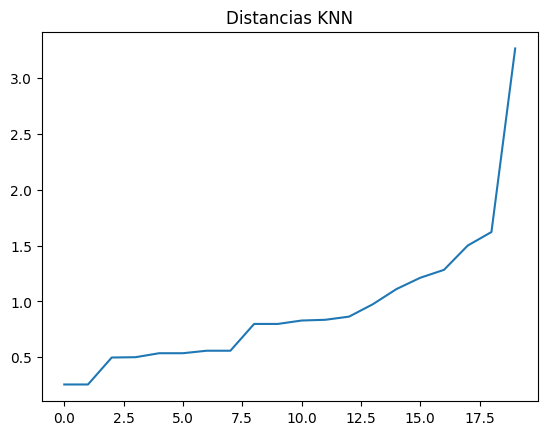

In [39]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,1])

plt.plot(distances)
plt.title("Distancias KNN")
plt.show()